In [1]:
import sys
sys.path.append('..')

from scipy.sparse.csgraph import shortest_path
from directed_persistence.ph_tools import persistence_dgms, plot_dgms


plt.style.use('seaborn-v0_8-deep')
plt.rcParams['axes.facecolor'] = 'white'

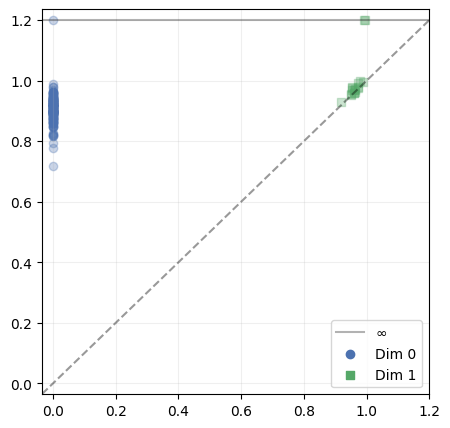

In [3]:
numHoles = 3
numTrial = 119

import scipy.io
mat = scipy.io.loadmat('../../simHippo/allDissim/t_dissim_'+str(numHoles)+'_'+str(numTrial)[1:]+'.mat')
mat = mat['dissim']

# Shift edge weights to start at zero
#mat -= np.min(mat)

for i in range(mat.shape[0]):
    for j in range(mat.shape[0]):
        mat[i,j] = max(mat[i,j],mat[j,i])
mat[mat==1] = np.inf

print('Working on network', numHoles, str(numTrial)[1:], 'with size', mat.shape[0], end='\r', flush=True)

f = gudhi.RipsComplex(distance_matrix=mat)
f = f.create_simplex_tree(max_dimension=2)
dgms = persistence_dgms(f)

plt.figure(figsize=(5,5))
plot_dgms(dgms, alpha=0.3, inf_val=1.2);
#plt.savefig('../../figures/hippocampal-networks-diagrams/walklen_min_dgm_'+str(numHoles)+'_'+str(numTrial)[1:]+'_'+str(mat.shape[0])+'.png', dpi=400);
#plt.close()

dgms = dgms.T

#filename = '../../hippocampal-networks/dowker/walklen_min_dgms_hipponet_'+str(numHoles)+'_'+str(numTrial)[1:]+'.csv'

import csv
#with open(filename, 'w', newline='') as file:
#    writer = csv.writer(file)
#    writer.writerows(dgms_as_np)
#file.close()

numTrial += 1

KeyboardInterrupt: 

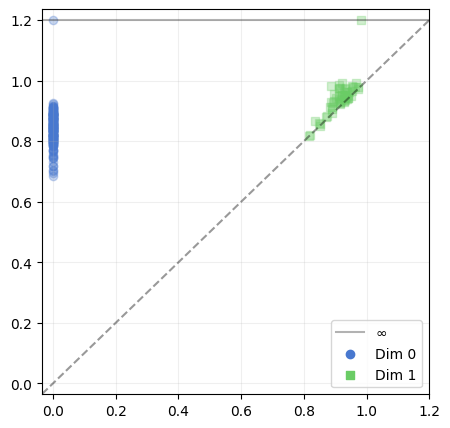

In [3]:
for numHoles in range(5):
    numTrial = 101

    while numTrial <= 120:
        import scipy.io
        mat = scipy.io.loadmat('../../simHippo/allDissim/t_dissim_'+str(numHoles)+'_'+str(numTrial)[1:]+'.mat')
        mat = mat['dissim']

        # Min symmetrization
        for i in range(mat.shape[0]):
            for j in range(mat.shape[0]):
                mat[i,j] = min(mat[i,j],mat[j,i])

        # Shift edge weights to start at zero
        #mat -= np.min(mat)
        #mat[mat==np.max(mat)] = 1

        # Purge unwanted edges
        mat[mat==1] = np.inf

        prep = 'purge'

        print('Working on network', numHoles, str(numTrial)[1:], 'with size', mat.shape[0], 'with prep', prep, end='\r', flush=True)

        f = gudhi.RipsComplex(distance_matrix=mat)
        f = f.create_simplex_tree(max_dimension=2)
        dgms = persistence_dgms(f)

        plt.figure(figsize=(5,5))
        plot_dgms(dgms, alpha=0.3, inf_val=1.2);
        plt.savefig('../../hippocampal-networks/dgms_png/dgm_ripsmin_'+prep+'_'+str(numHoles)+'_'+str(numTrial)[1:]+'.png', dpi=400);
        plt.close()

        dgms = dgms.T

        filename = '../../hippocampal-networks/dgms_csv/dgm_ripsmin_'+prep+'_'+str(numHoles)+'_'+str(numTrial)[1:]+'.csv'

        import csv
        with open(filename, 'w', newline='') as file:
            writer = csv.writer(file)
            writer.writerows(dgms)
        file.close()

        numTrial += 1

In [ ]:
preprocs = ['original','min1', 'minpurge', 'purge']